In [1]:
import fsspec
import xarray as xr
import zarr
import rioxarray 
import matplotlib.pyplot as plt
import psutil
from IPython.core.magic import register_cell_magic

In [2]:
# @register_cell_magic
# def netwatch(line, cell):
#     before = psutil.net_io_counters()
#     exec(cell, globals())
#     after = psutil.net_io_counters()
#     recv = after.bytes_recv - before.bytes_recv
#     sent = after.bytes_sent - before.bytes_sent
#     print(f"\nNetwork: {recv/(1024**2):.1f} MB recv, {sent/(1024**2):.1f} MB sent")

In [3]:
# import logging

# logging.getLogger("fsspec").setLevel(logging.DEBUG)
# logging.getLogger("urllib3.connectionpool").setLevel(logging.DEBUG)

# # Route to notebook output instead of stderr
# logging.basicConfig(format="%(name)s %(levelname)s: %(message)s", force=True)

In [4]:
# %%netwatch
# zenodo_url = "https://zenodo.org/records/15226841/files/nsclc4301_truncated.zarr.tar?download=1"
# zarr_file = "nsclc4301_truncated.zarr"

# zenodo_url = "https://zenodo.org/records/16803637/files/expAE03_04_q05m95_flux.zarr.tar?download=1"
# zarr_file = "expAE03_04_q05m95_flux.zarr"

# zenodo_url = "https://zenodo.org/records/6557396/files/lmmm_eta_nemo.zarr.tar?download=1"
# zarr_file = "lmmm_eta_nemo.zarr"

# %%netwatch
# fs = fsspec.filesystem("tar", fo=zenodo_url)
# store = fs.get_mapper(zarr_file)
# ds = xr.open_zarr(store, chunks="auto", consolidated=True)
# ds['eta'].isel(mode=0,time=1).plot.imshow()

# zenodo_url = "https://zenodo.org/records/19699063/files/global_snowmelt_runoff_onset_WY2015.zarr.tar?download=1"
# zarr_file = "global_snowmelt_runoff_onset_WY2015.zarr"


In [5]:
# %%netwatch
import fsspec
import xarray as xr
import matplotlib.pyplot as plt

REF_JSON_URL = "https://zenodo.org/records/19618062/files/global_snowmelt_runoff_onset.zarr.tar.refs.json"
mapper = fsspec.get_mapper("reference://",fo=REF_JSON_URL,remote_protocol="https")
global_ds = xr.open_zarr(mapper, consolidated=False, decode_coords="all")
global_ds

<xarray.Dataset> Size: 14TB
Dimensions:                     (latitude: 195970, longitude: 499998,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [10]:
southern_alps_ds = global_ds[["runoff_onset","runoff_onset_median"]].rio.clip_box(minx=169.5, miny=-44, maxx=171.3, maxy=-43, crs="EPSG:4326").compute()
southern_alps_ds

<xarray.Dataset> Size: 153MB
Dimensions:              (latitude: 1390, longitude: 2501, water_year: 10)
Coordinates:
  * latitude             (latitude) float64 11kB -43.0 -43.0 ... -44.0 -44.0
  * longitude            (longitude) float64 20kB 169.5 169.5 ... 171.3 171.3
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
    spatial_ref          int64 8B 0
Data variables:
    runoff_onset         (water_year, latitude, longitude) float32 139MB nan ...
    runoff_onset_median  (latitude, longitude) float32 14MB nan nan ... nan nan
Attributes:
    processed_tiles:  []

In [11]:
southern_alps_utm_ds = southern_alps_ds.rio.reproject(southern_alps_ds.rio.estimate_utm_crs())
southern_alps_utm_ds

<xarray.Dataset> Size: 177MB
Dimensions:              (x: 2293, y: 1753, water_year: 10)
Coordinates:
  * x                    (x) float64 18kB 3.777e+05 3.778e+05 ... 5.245e+05
  * y                    (y) float64 14kB 5.239e+06 5.239e+06 ... 5.127e+06
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
    spatial_ref          int64 8B 0
Data variables:
    runoff_onset         (water_year, y, x) float32 161MB nan nan ... nan nan
    runoff_onset_median  (y, x) float32 16MB nan nan nan nan ... nan nan nan nan
Attributes:
    processed_tiles:  []

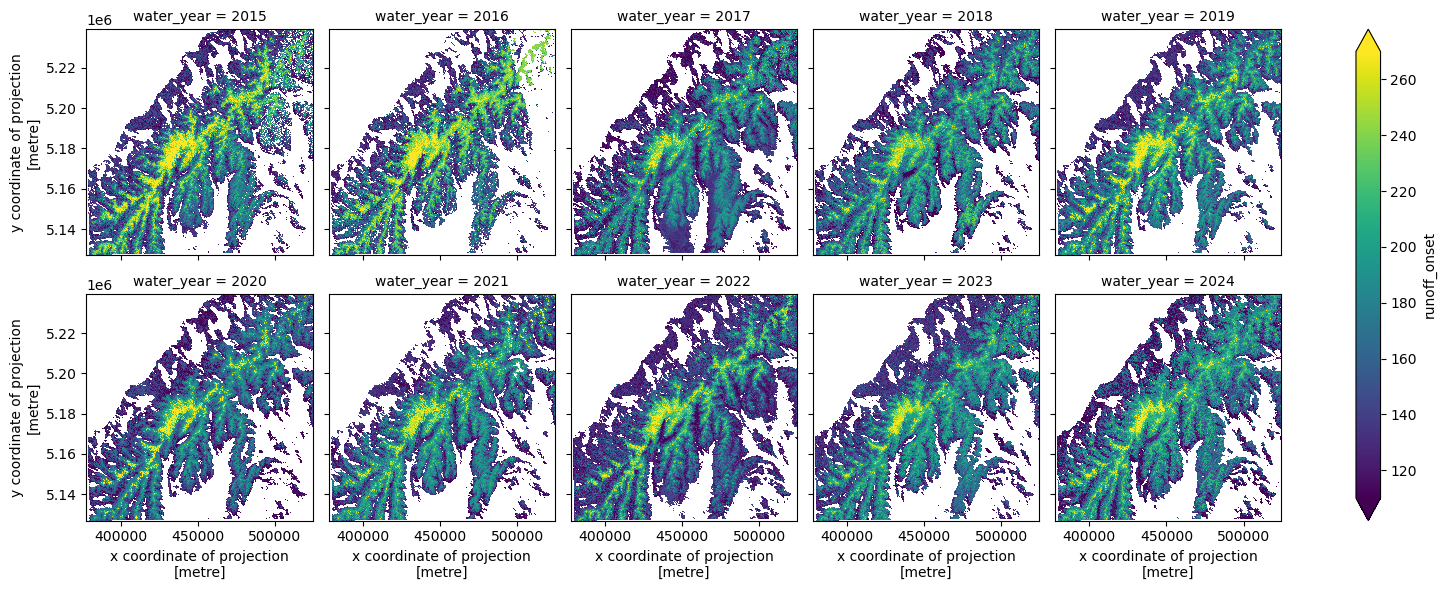

In [12]:
southern_alps_utm_ds["runoff_onset"].plot.imshow(col='water_year', col_wrap=5, cmap='viridis', vmin=110, vmax=270, subplot_kws={'aspect': 'equal'})

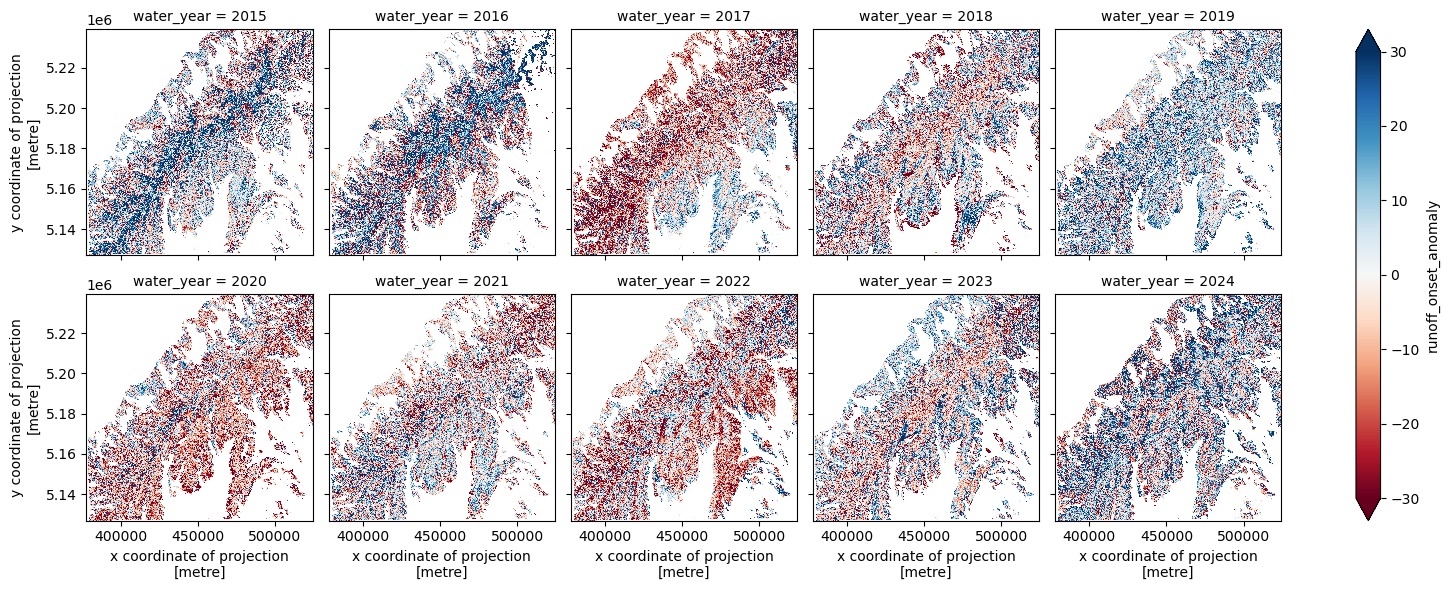

In [13]:
southern_alps_utm_ds["runoff_onset_anomaly"] = southern_alps_utm_ds["runoff_onset"] - southern_alps_utm_ds["runoff_onset_median"]
southern_alps_utm_ds["runoff_onset_anomaly"].plot.imshow(col='water_year', col_wrap=5, cmap='RdBu', vmin=-30, vmax=30, subplot_kws={'aspect': 'equal'})

In [ ]:
import numpy as np
def count_total_dataset_chunks(ds):
    total_chunks = 0
    for var_name in ds.data_vars:
        if ds[var_name].chunks is not None:
            n = np.prod([len(c) for c in ds[var_name].chunks])
            print(f"{var_name}: {n} chunks")
            total_chunks += n
    print(f"Total chunks: {total_chunks}")

count_total_dataset_chunks(southern_alps_ds)

In [ ]:
# %%netwatch
rainier_ds = global_ds.rio.clip_box(minx=-122, miny=46.7, maxx=-121.5, maxy=47, crs="EPSG:4326").compute()
rainier_ds

In [ ]:
rainier_utm_ds = rainier_ds.rio.reproject("EPSG:32610")
rainier_utm_ds

In [ ]:
rainier_utm_ds["runoff_onset"].plot.imshow(col='water_year', col_wrap=5, cmap='viridis', vmin=110, vmax=270)#, subplot_kws={'aspect': 'equal'})


In [ ]:
rainier_utm_ds["runoff_onset"].plot.imshow(col='water_year', col_wrap=5, cmap='viridis', vmin=110, vmax=270, subplot_kws={'aspect': 'equal'})


In [ ]:
f, axs = plt.subplots(figsize=(12, 3), ncols=3, nrows=1)
rainier_utm_ds["runoff_onset_median"].plot.imshow(
    ax=axs[0], cmap='viridis', vmin=110, vmax=270,
    cbar_kwargs={'label': 'day of water year'},
)
rainier_utm_ds["runoff_onset_mad"].plot.imshow(
    ax=axs[1], cmap='Reds', vmin=0, vmax=60,
    cbar_kwargs={'label': 'days'},
)
rainier_utm_ds["temporal_resolution_median"].plot.imshow(
    ax=axs[2], cmap='summer', vmin=1, vmax=20,
    cbar_kwargs={'label': 'days'},
)

for ax in axs:
    ax.axis('off')
    ax.set_aspect('equal')

axs[0].set_title("10-year median snowmelt runoff onset")
axs[1].set_title("10-year median absolute deviation")
axs[2].set_title("10-year local median temporal resolution")
f.tight_layout()

In [ ]:
rainier_utm_ds["runoff_onset"].plot.imshow(col='water_year', col_wrap=5, cmap='viridis', vmin=110, vmax=270, subplot_kws={'aspect': 'equal'})

rainier_utm_ds["temporal_resolution"].plot.imshow(col='water_year', col_wrap=5, cmap='summer', vmin=1, vmax=20, subplot_kws={'aspect': 'equal'})

# Access Method Benchmark: Kerchunk (Zenodo) vs Azure Zarr

Compare download speed and bytes transferred for two access patterns across four spatial extents (1, 10, 100, 1000 km) and four mountain range locations.

In [ ]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# --- Locations: (name, center_lon, center_lat) ---
LOCATIONS = [
    ("WA Cascades",      -121.75,  46.85),
    ("Karakoram",    76.50,  36.00),
    ("European Alps",       8.00,  46.50),
    ("NZ Southern Alps",  170.00, -44.00),
]

# Spatial extents to test (km side length of square box)
SIZES_KM = [1, 10, 100, 200]

# Access method configs
REF_JSON_URL  = "https://zenodo.org/records/19618062/files/global_snowmelt_runoff_onset.zarr.tar.refs.json"
AZURE_ZARR_URL = "https://uwcryo.blob.core.windows.net/snowmelt/snowmelt_runoff_onset/global_v9.zarr"

In [ ]:
def km_to_deg(km, center_lat):
    """Convert a km distance to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(center_lat)))
    return lat_deg, lon_deg

def make_bbox(center_lon, center_lat, size_km):
    half_lat, half_lon = km_to_deg(size_km / 2, center_lat)
    return dict(
        minx=center_lon - half_lon,
        maxx=center_lon + half_lon,
        miny=center_lat - half_lat,
        maxy=center_lat + half_lat,
        crs="EPSG:4326",
    )

def benchmark_clip(ds, bbox):
    """Clip, compute, and return timing + network stats."""
    subset = ds.rio.clip_box(**bbox)

    bytes_before = psutil.net_io_counters().bytes_recv
    t0 = time.perf_counter()

    result = subset.compute()

    elapsed = time.perf_counter() - t0
    mb_downloaded = (psutil.net_io_counters().bytes_recv - bytes_before) / 1e6
    mb_in_memory  = result.nbytes / 1e6

    return elapsed, mb_downloaded, mb_in_memory

In [ ]:
# Open both datasets lazily — minimal data transfer at this step

print("Opening Kerchunk/reference dataset (Zenodo)...")
mapper = fsspec.get_mapper("reference://", fo=REF_JSON_URL, remote_protocol="https")
ds_ref = xr.open_zarr(mapper, consolidated=False, decode_coords="all", mask_and_scale=False)
print(ds_ref)

print("\nOpening Azure Zarr dataset...")
ds_azure = xr.open_zarr(AZURE_ZARR_URL, consolidated=True, decode_coords="all")
print(ds_azure)

In [ ]:
bbox = make_bbox(center_lon=76.50, center_lat=36.00, size_km=1000)
subset = ds_ref.rio.clip_box(**bbox)#.compute()
subset

In [ ]:
import numpy as np
def count_chunks(ds):
    return sum(np.prod([len(c) for c in ds[v].chunks])
               for v in ds.data_vars if ds[v].chunks is not None)
print(count_chunks(subset))

In [ ]:
subset.sel(water_year=slice(2019,2020))

In [ ]:
def count_total_dataset_chunks(ds):
    total_chunks = 0
    for var_name in ds.data_vars:
        if ds[var_name].chunks is not None:
            n = np.prod([len(c) for c in ds[var_name].chunks])
            print(f"{var_name}: {n} chunks")
            total_chunks += n
    print(f"Total chunks: {total_chunks}")

count_total_dataset_chunks(subset)

In [ ]:
import time

import dask
import fsspec
import numpy as np
import xarray as xr
import rioxarray  # noqa: F401

REF_JSON_URL = (
    "https://zenodo.org/records/19618062/files/"
    "global_snowmelt_runoff_onset.zarr.tar.refs.json"
)

# Mt. Rainier-ish center, expanded in roughly log steps.
# (name, half_width_degrees, roughly_km_per_side)
TESTS = [
    ("~50 km box",   0.25,  50),
    ("~100 km box",  0.5,   100),
    ("~200 km box",  1.0,   200),
    ("~500 km box",  2.5,   500),
    ("~1000 km box", 5.0,   1000),
    ("~1500 km box", 7.5,   1500),
    ("~2000 km box", 10.0,  2000),
    ("~5000 km box", 25.0,  5000),
]

CENTER_LON, CENTER_LAT = -121.75, 46.85
COOLDOWN_SEC = 60  # Zenodo's rate-limit window is ~60s; this gives clean gaps


def open_dataset():
    mapper = fsspec.get_mapper(
        "reference://",
        fo=REF_JSON_URL,
        remote_protocol="https",
    )
    return xr.open_zarr(mapper, consolidated=False, decode_coords="all")


def count_chunks(ds):
    """Return {var_name: n_chunks} for all data variables + total."""
    counts = {}
    for var_name in ds.data_vars:
        if ds[var_name].chunks is not None:
            counts[var_name] = int(np.prod([len(c) for c in ds[var_name].chunks]))
        else:
            counts[var_name] = 1  # unchunked = single chunk
    counts["_total"] = sum(v for k, v in counts.items() if k != "_total")
    return counts


def estimate_bytes(ds):
    """Raw decoded bytes (int16 so pixels * 2). Real wire bytes are smaller."""
    return sum(ds[v].size for v in ds.data_vars) * 2


def run_test(name, half, km, variables, num_workers):
    ds = open_dataset()
    sub = ds[variables].rio.clip_box(
        minx=CENTER_LON - half, maxx=CENTER_LON + half,
        miny=CENTER_LAT - half, maxy=CENTER_LAT + half,
        crs="EPSG:4326",
    )

    chunks = count_chunks(sub)
    raw_mb = estimate_bytes(sub) / 1e6

    chunk_str = ", ".join(f"{k}={v}" for k, v in chunks.items() if k != "_total")
    print(f"\n{name} ({km} km/side) | vars={variables} | workers={num_workers}")
    print(f"  raw data: {raw_mb:.1f} MB")
    print(f"  chunks:   {chunks['_total']} total ({chunk_str})")

    t0 = time.time()
    try:
        with dask.config.set(scheduler="threads", num_workers=num_workers):
            _ = sub.compute()
        dt = time.time() - t0
        chunks_per_sec = chunks["_total"] / dt
        print(f"  OK in {dt:.1f}s "
              f"({raw_mb / dt:.2f} MB/s raw, {chunks_per_sec:.1f} chunks/s)")
        return {"status": "ok", "time": dt, "chunks": chunks["_total"],
                "raw_mb": raw_mb}
    except Exception as e:
        dt = time.time() - t0
        msg = str(e)
        if "429" in msg or "TOO MANY" in msg:
            reason = "RATE LIMITED (429)"
        elif "timeout" in msg.lower():
            reason = "TIMEOUT"
        else:
            reason = "OTHER"
        print(f"  FAILED after {dt:.1f}s: {reason}")
        print(f"  {msg.splitlines()[0][:200]}")
        return {"status": "fail", "reason": reason, "time": dt,
                "chunks": chunks["_total"], "raw_mb": raw_mb}


def run_phase(phase_num, description, variables, num_workers):
    print("\n" + "=" * 70)
    print(f"PHASE {phase_num}: {description}")
    print("=" * 70)

    results = []
    for i, (name, half, km) in enumerate(TESTS):
        result = run_test(name, half, km, variables, num_workers)
        result.update({"name": name, "km": km})
        results.append(result)
        if result["status"] == "fail":
            break
        if i < len(TESTS) - 1:
            print(f"  ...cooling down {COOLDOWN_SEC}s")
            time.sleep(COOLDOWN_SEC)
    return results


def summarize(all_results):
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"{'Phase':<8}{'Box':<15}{'Status':<18}{'Chunks':>8}"
          f"{'Raw MB':>10}{'Time (s)':>10}")
    print("-" * 70)
    for phase, results in all_results.items():
        for r in results:
            status = r["status"] if r["status"] == "ok" else r["reason"]
            print(f"{phase:<8}{r['name']:<15}{status:<18}"
                  f"{r['chunks']:>8}{r['raw_mb']:>10.1f}{r['time']:>10.1f}")


# === Run the sweep ===
all_results = {}

all_results["P1"] = run_phase(
    1, "composites only (1 var, 2D), 1 worker",
    ["runoff_onset_median"], num_workers=1,
)

print(f"\n...{COOLDOWN_SEC}s cooldown between phases")
time.sleep(COOLDOWN_SEC)

all_results["P2"] = run_phase(
    2, "composites only (1 var, 2D), 4 workers",
    ["runoff_onset_median"], num_workers=4,
)

print(f"\n...{COOLDOWN_SEC}s cooldown between phases")
time.sleep(COOLDOWN_SEC)

all_results["P3"] = run_phase(
    3, "all 3 composite vars (3 var, 2D), 4 workers",
    ["runoff_onset_median", "runoff_onset_mad", "temporal_resolution_median"],
    num_workers=4,
)

print(f"\n...{COOLDOWN_SEC}s cooldown between phases")
time.sleep(COOLDOWN_SEC)

all_results["P4"] = run_phase(
    4, "annual runoff_onset (1 var, 3D), 4 workers",
    ["runoff_onset"], num_workers=4,
)

summarize(all_results)

In [ ]:
import dask

In [ ]:
with dask.config.set(scheduler='synchronous'):
    bbox = make_bbox(center_lon=76.50, center_lat=36.00, size_km=1000)
    subset = ds_ref.rio.clip_box(**bbox).compute()
subset

In [ ]:
subset_utm_ds = subset.rio.reproject(subset.rio.estimate_utm_crs())
subset_utm_ds

In [ ]:
f, axs = plt.subplots(figsize=(12, 3), ncols=3, nrows=1)
subset_utm_ds["runoff_onset_median"].plot.imshow(
    ax=axs[0], cmap='viridis', vmin=110, vmax=270,
    cbar_kwargs={'label': 'day of water year'},
)
subset_utm_ds["runoff_onset_mad"].plot.imshow(
    ax=axs[1], cmap='Reds', vmin=0, vmax=60,
    cbar_kwargs={'label': 'days'},
)
subset_utm_ds["temporal_resolution_median"].plot.imshow(
    ax=axs[2], cmap='summer', vmin=1, vmax=20,
    cbar_kwargs={'label': 'days'},
)

for ax in axs:
    ax.axis('off')
    ax.set_aspect('equal')

axs[0].set_title("10-year median snowmelt runoff onset")
axs[1].set_title("10-year median absolute deviation")
axs[2].set_title("10-year local median temporal resolution")
f.tight_layout()

subset_utm_ds["runoff_onset"].plot.imshow(col='water_year', col_wrap=5, cmap='viridis', vmin=110, vmax=270, subplot_kws={'aspect': 'equal'})

subset_utm_ds["temporal_resolution"].plot.imshow(col='water_year', col_wrap=5, cmap='summer', vmin=1, vmax=20, subplot_kws={'aspect': 'equal'})

In [ ]:
from itertools import product as iproduct

METHODS = {
    "Kerchunk (Zenodo)": ds_ref,
    "Azure Zarr":        ds_azure,
}

records = []

for (loc_name, clon, clat), size_km in iproduct(LOCATIONS, SIZES_KM):
    bbox = make_bbox(clon, clat, size_km)

    for method_name, ds in METHODS.items():
        tag = f"{method_name:22s} | {loc_name:20s} | {size_km:>5} km"
        print(f"  {tag} ... ", end="", flush=True)
        try:
            elapsed, mb_dl, mb_mem = benchmark_clip(ds, bbox)
            print(f"{elapsed:6.2f}s  {mb_dl:7.2f} MB downloaded  ({mb_mem:.2f} MB in-memory)")
            records.append(dict(
                method=method_name, location=loc_name, size_km=size_km,
                elapsed_s=elapsed, mb_downloaded=mb_dl, mb_in_memory=mb_mem,
            ))
        except Exception as exc:
            print(f"ERROR: {exc}")
            records.append(dict(
                method=method_name, location=loc_name, size_km=size_km,
                elapsed_s=np.nan, mb_downloaded=np.nan, mb_in_memory=np.nan,
            ))

results_df = pd.DataFrame(records)
print("\nAll done.")

In [ ]:
# Summary pivot table: mean ± std across the four locations
summary = (
    results_df
    .groupby(["method", "size_km"])[["elapsed_s", "mb_downloaded", "mb_in_memory"]]
    .agg(["mean", "std"])
    .round(2)
)
summary.columns = ["_".join(c) for c in summary.columns]
display(summary)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHOD_COLORS = {
    "Kerchunk (Zenodo)": "#1f77b4",
    "Azure Zarr":        "#ff7f0e",
}

METRICS = [
    ("elapsed_s",     "Download Time (s)"),
    ("mb_downloaded", "Data Downloaded (MB)"),
    ("mb_in_memory",  "Data in Memory (MB)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
flat_axes = axes.flatten()

# --- Top 3 panels: one metric each, averaged over locations ---
for ax, (metric, ylabel) in zip(flat_axes[:3], METRICS):
    for method, color in METHOD_COLORS.items():
        sub = results_df[results_df["method"] == method]
        grp = sub.groupby("size_km")[metric].agg(["mean", "std"]).reset_index()
        ax.errorbar(grp["size_km"], grp["mean"], yerr=grp["std"],
                    label=method, color=color, marker="o", capsize=4, linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Spatial Extent (km side)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + "\n(mean ± std over 4 locations)")
    ax.set_xticks(SIZES_KM)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

# --- Bottom-right panel: throughput (MB in-memory / s) ---
ax = flat_axes[3]
for method, color in METHOD_COLORS.items():
    sub = results_df[results_df["method"] == method].copy()
    sub["throughput"] = sub["mb_in_memory"] / sub["elapsed_s"]
    grp = sub.groupby("size_km")["throughput"].agg(["mean", "std"]).reset_index()
    ax.errorbar(grp["size_km"], grp["mean"], yerr=grp["std"],
                label=method, color=color, marker="o", capsize=4, linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("Spatial Extent (km side)")
ax.set_ylabel("Throughput (MB in-memory / s)")
ax.set_title("Effective Throughput\n(mean ± std over 4 locations)")
ax.set_xticks(SIZES_KM)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Access Method Comparison: Kerchunk (Zenodo) vs Azure Zarr", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("access_method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Per-location breakdown: does chunking layout differ by region?
loc_names = [loc[0] for loc in LOCATIONS]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

panel_configs = [
    (0, 0, "elapsed_s",     "Download Time (s)",    "Kerchunk (Zenodo)"),
    (0, 1, "elapsed_s",     "Download Time (s)",    "Azure Zarr"),
    (1, 0, "mb_downloaded", "Data Downloaded (MB)", "Kerchunk (Zenodo)"),
    (1, 1, "mb_downloaded", "Data Downloaded (MB)", "Azure Zarr"),
]

for row, col, metric, ylabel, method in panel_configs:
    ax = axes[row, col]
    sub = results_df[results_df["method"] == method]
    for loc_name in loc_names:
        loc_sub = sub[sub["location"] == loc_name].sort_values("size_km")
        ax.plot(loc_sub["size_km"], loc_sub[metric], marker="o", label=loc_name, linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Spatial Extent (km side)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{method}\n{ylabel}")
    ax.set_xticks(SIZES_KM)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Per-Location Breakdown (chunking variability)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("access_method_per_location.png", dpi=150, bbox_inches="tight")
plt.show()